Accuracy: 0.9902912621359223
Precision: 0.9803921568627451
Recall: 1.0
F1 Score: 0.99009900990099
ROC AUC: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99        53
           1       0.98      1.00      0.99        50

    accuracy                           0.99       103
   macro avg       0.99      0.99      0.99       103
weighted avg       0.99      0.99      0.99       103


Class-wise Accuracy:
Cystitis (0): 0.98
Bladder Cancer (1): 1.00


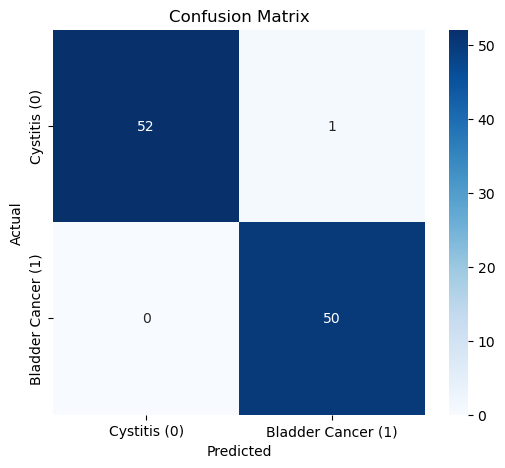

In [3]:
# pip install pandas scikit-learn imbalanced-learn matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import RFE
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix
)
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from imblearn.over_sampling import SMOTE

# -------------------------
# 1. Load dataset
# -------------------------
df = pd.read_csv("bladder1_labeled.csv")  # Replace with your dataset path

# Target column: label (0 = cystitis, 1 = bladder cancer)
X = df.drop(columns=['label'])
y = df['label']

# Encode categorical variables
for col in X.select_dtypes(include=['object']).columns:
    X[col] = LabelEncoder().fit_transform(X[col])

# Handle missing values
X = X.fillna(X.median())

# -------------------------
# 2. Handle class imbalance
# -------------------------
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# -------------------------
# 3. Feature Selection (RFE)
# -------------------------
estimator = RandomForestClassifier(random_state=42)
selector = RFE(estimator, n_features_to_select=10)
X_selected = selector.fit_transform(X_resampled, y_resampled)

# -------------------------
# 4. Dimensionality Reduction (PCA)
# -------------------------
pca = PCA(n_components=5)
X_pca = pca.fit_transform(X_selected)

# -------------------------
# 5. Train-Test Split
# -------------------------
X_train, X_test, y_train, y_test = train_test_split(X_pca, y_resampled, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# -------------------------
# 6. Base Models
# -------------------------
svm = SVC(probability=True, kernel='rbf', random_state=42)
rf = RandomForestClassifier(random_state=42)
knn = KNeighborsClassifier()
gb = GradientBoostingClassifier(random_state=42)

# -------------------------
# 7. Ensemble Model (Voting Classifier)
# -------------------------
voting_clf = VotingClassifier(
    estimators=[('svm', svm), ('rf', rf), ('knn', knn), ('gb', gb)],
    voting='soft'
)

# Train ensemble
voting_clf.fit(X_train, y_train)

# -------------------------
# 8. Predictions & Evaluation
# -------------------------
y_pred = voting_clf.predict(X_test)
y_proba = voting_clf.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# -------------------------
# 9. Class-wise Accuracy
# -------------------------
class_labels = ['Cystitis (0)', 'Bladder Cancer (1)']
class_accuracies = []

for label in np.unique(y_test):
    idx = (y_test == label)
    acc = accuracy_score(y_test[idx], y_pred[idx])
    class_accuracies.append(acc)

print("\nClass-wise Accuracy:")
for label, acc in zip(class_labels, class_accuracies):
    print(f"{label}: {acc:.2f}")

# -------------------------
# 10. Confusion Matrix Plot
# -------------------------
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues",
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()
